In [2]:
# single-cell analysis package
library(Seurat)

# plotting and data science packages
library(repr)
library(stringr)
library(dplyr) 
library(tidyverse)
library(ggplot2)
library(cowplot)
library(patchwork)

# co-expression network analysis packages:
library(WGCNA)
library(hdWGCNA)

# enable parallel processing for network analysis (optional)
enableWGCNAThreads(nThreads = 8)

# using the cowplot theme for ggplot
theme_set(theme_cowplot())

# set random seed for reproducibility
set.seed(12345)

Allowing parallel execution with up to 8 working processes.


## Load the data

In [3]:
# Output Directory
outDir <- file.path("./results")

# load the processed dataset
stObj <- readRDS(file.path('./results/HGSOC_ST_seurat_processed.rds'))
# set idents
Idents(stObj) <- stObj$cell_type

print(stObj)
print(table(stObj@meta.data$patient))
print(table(stObj@meta.data$chemotherapy_response))

An object of class Seurat 
33538 features across 19996 samples within 1 assay 
Active assay: Spatial (33538 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne
 8 spatial fields of view present: P1 P2 P3 P4 P5 P6 P7 P8

  P1   P2   P3   P4   P5   P6   P7   P8 
2925 1920 1498 3002 2104 1792 3589 3166 

   good partial    poor 
   5522    4794    9680 


In [4]:
## Subset Tumor cell only
stObj <- subset(stObj, cell_type %in% c("Tumour_cells"))
stObj$cell_type <- as.factor(stObj$cell_type)
stObj$patient <- as.factor(stObj$patient)
stObj$chemotherapy_response <- as.factor(stObj$chemotherapy_response)

stObj$cell_type <- droplevels(stObj$cell_type)
stObj$patient <- droplevels(stObj$patient)
stObj$chemotherapy_response <- droplevels(stObj$chemotherapy_response)

print(stObj)
print(table(stObj@meta.data$patient))
print(table(stObj@meta.data$chemotherapy_response))

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV o

An object of class Seurat 
33538 features across 11472 samples within 1 assay 
Active assay: Spatial (33538 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne
 8 spatial fields of view present: P1 P2 P3 P4 P5 P6 P7 P8

  P1   P2   P3   P4   P5   P6   P7   P8 
2465  917  665 2576  153  167 3424 1105 

   good partial    poor 
   1735    2743    6994 


In [5]:
wgcna_obj <- SetupForWGCNA(
                  stObj,
                  gene_select = "fraction", # the gene selection approach
                  fraction = 0.05, # fraction of cells that a gene needs to be expressed in order to be included
                  wgcna_name = "HGSOC", # the name of the hdWGCNA experiment
                  group.by = c("cell_type")
                )

wgcna_obj@meta.data <- wgcna_obj@meta.data%>%mutate(chemotherapy_score=recode(chemotherapy_response,"poor"=1,"partial"=2,"good"=3))
print(wgcna_obj)
length(GetWGCNAGenes(wgcna_obj))

An object of class Seurat 
33538 features across 11472 samples within 1 assay 
Active assay: Spatial (33538 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne
 8 spatial fields of view present: P1 P2 P3 P4 P5 P6 P7 P8


[1] 11729

In [6]:
wgcna_obj <- MetaspotsByGroups(
                  wgcna_obj,
                  group.by = c("patient"),
                  ident.group = "patient",   ## set the Idents of the metaspot seurat object,
                  assay = 'Spatial'
                )
print(wgcna_obj)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validat

An object of class Seurat 
33538 features across 11472 samples within 1 assay 
Active assay: Spatial (33538 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne
 8 spatial fields of view present: P1 P2 P3 P4 P5 P6 P7 P8


In [7]:
wgcna_obj  <- NormalizeMetacells(wgcna_obj)
wgcna_obj

Normalizing layer: counts



An object of class Seurat 
33538 features across 11472 samples within 1 assay 
Active assay: Spatial (33538 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne
 8 spatial fields of view present: P1 P2 P3 P4 P5 P6 P7 P8

## Co-expression network analysis

In [8]:
# set up the expression matrix, set group.by and group_name to NULL to include all spots
wgcna_obj  <- SetDatExpr(
    wgcna_obj,
    group.by= "cell_type",
    group_name = 'Tumour_cells',
    use_metacells=TRUE,
    slot = 'data',
)

Warning message in SetDatExpr(wgcna_obj, group.by = "cell_type", group_name = "Tumour_cells", :
“assay not specified, trying to use assay Spatial”


pickSoftThreshold: will use block size 3814.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 3814 of 11729
   ..working on genes 3815 through 7628 of 11729
tem call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
      0.883 2.36e+02  2.33e+02  368.00
7      7   0.0759 -1.740          0.895 1.26e+02  1.23e+02  237.00
8      8   0.4670 -4.020          0.848 6.77e+01  6.54e+01  162.00
9      9   0.8320 -4.880          0.944 3.67e+01  3.48e+01  115.00
10    10   0.9330 -4.760

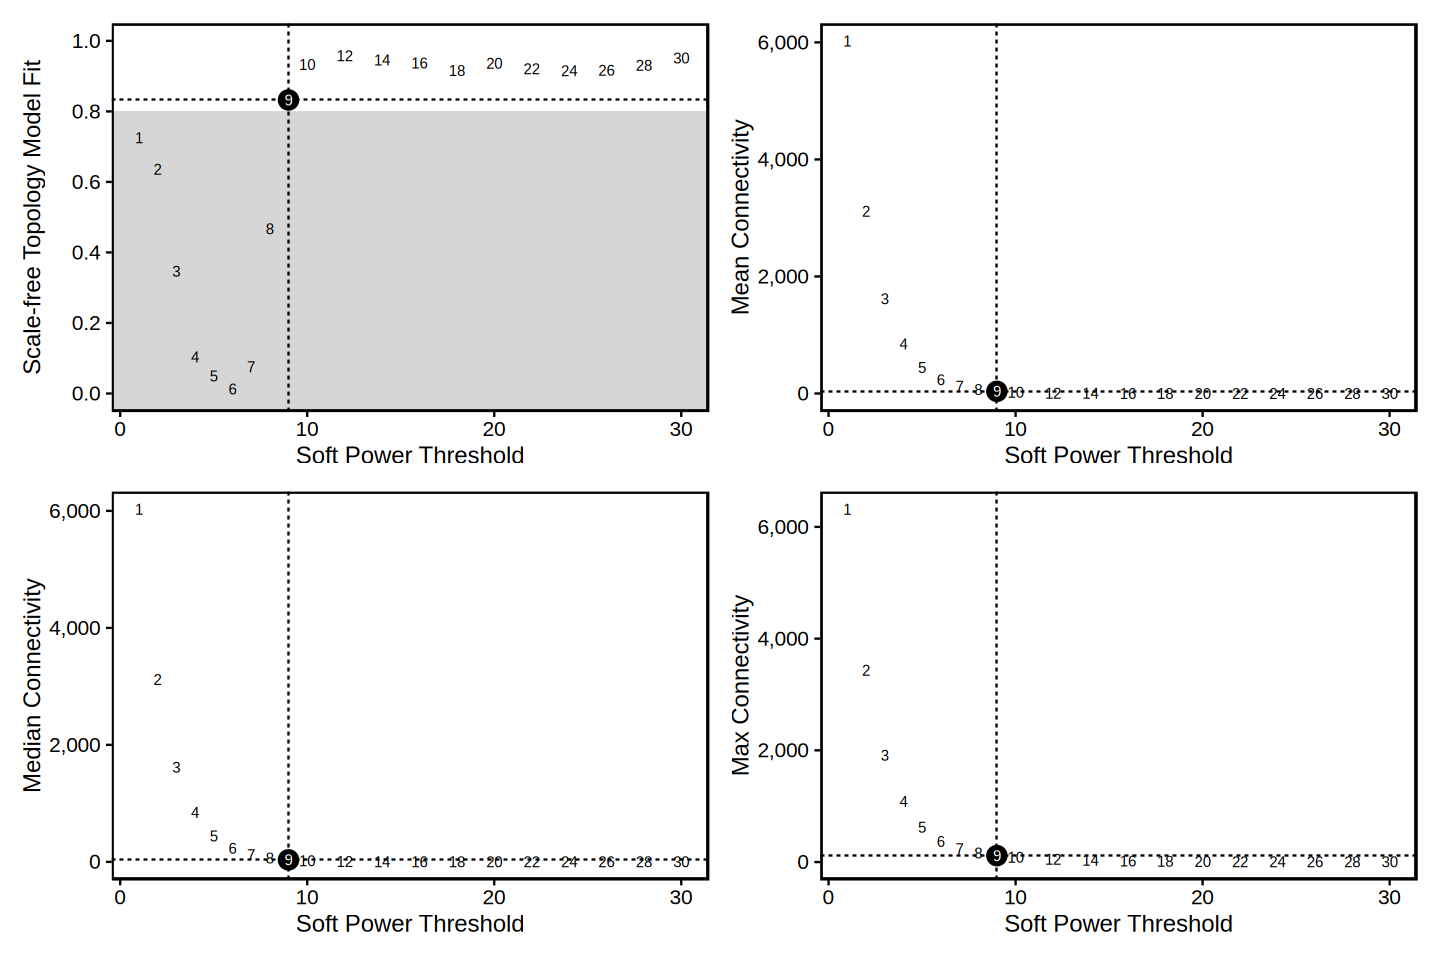

In [9]:
options(repr.plot.height = 8, repr.plot.width = 12)

# test different soft power thresholds
wgcna_obj <- TestSoftPowers(wgcna_obj)
plot_list <- PlotSoftPowers(wgcna_obj)

wrap_plots(plot_list, ncol=2)

Soft power not provided. Automatically using the lowest power that meets 0.8 scale-free topology fit. Using soft_power = 9
 Calculating consensus modules and module eigengenes block-wise from all genes
 Calculating topological overlaps block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
    TOM calculation: adjacency..
    ..will use 8 parallel threads.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
 ..Working on block 1 .
 ..Working on block 1 .
 ..merging consensus modules that are too close..


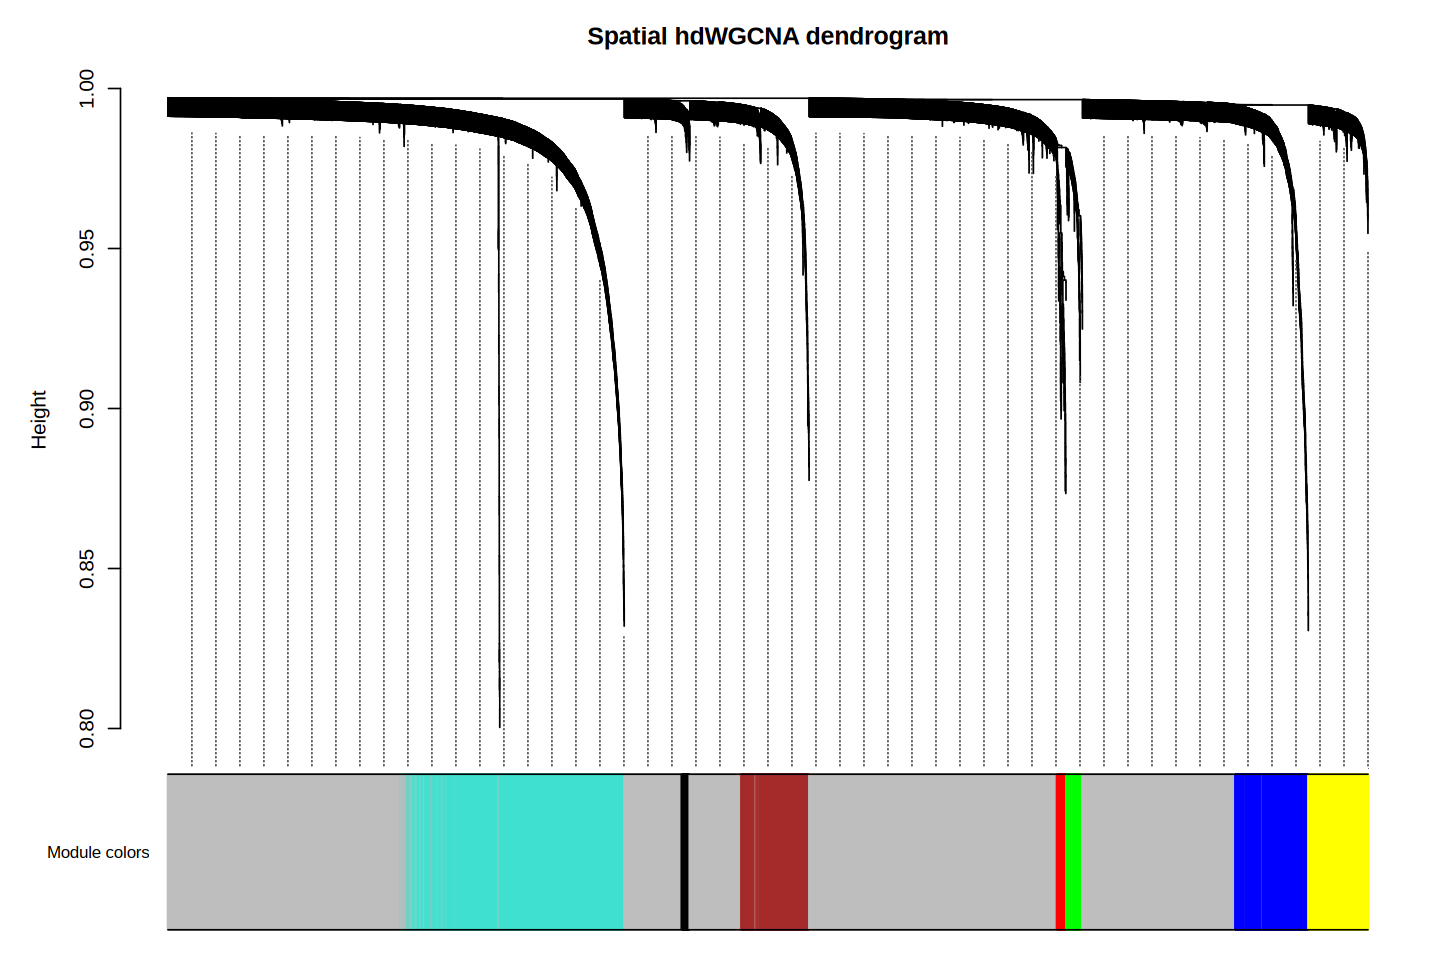

In [10]:
# construct co-expression network:
wgcna_obj <- ConstructNetwork(
  wgcna_obj,
  tom_name='tumour_cells',
  overwrite_tom=TRUE
)

# plot the dendrogram
# pdf(paste0(fig_dir, "5x_dendro.pdf"),height=3, width=6)
# plot the dendrogram
PlotDendrogram(wgcna_obj, main='Spatial hdWGCNA dendrogram')
# dev.off()

## Module Eigengene

In [11]:
#  harmonized module eigengenes (hMEs)
wgcna_obj <- ModuleEigengenes(wgcna_obj, group.by.vars="patient")
hMEs <- GetMEs(wgcna_obj)

[1] "brown"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcabrown to pcabrown_”
pcabrown_ 1 
Positive:  ACVRL1, FIBIN, CNRIP1, RUNX1T1, SLFN11, TENT5A, CHRD, IL15RA, PTPN13, ATP6V1C2 
	   SLC24A3, KIF26B, RASSF2, MEIS3, STK10, FGD3, S1PR3, PPM1F, ELL2, GPSM3 
	   PDGFD, TRPV2, CRYGS, TGFB1, ABCC4, ZEB2, NKD2, CEMIP2, ITGAM, CCNE1 
Negative:  IGHG1, IGLC2, IGLC3, IGKC, IGHG3, IGHM, IGHG4, IGHGP, IGHA1, CTSK 
	   COL3A1, SFRP2, MZB1, LUM, POSTN, HLA-B, LYZ, SPARC, IGHG2, COL6A1 
	   MMP2, APOC1, COL1A1, COL6A3, COL6A2, APOE, HTRA1, HLA-A, COL5A2, C1QB 
pcabrown_ 2 
Positive:  COL1A1, COL1A2, SFRP2, COL3A1, CTSK, COL5A2, IGHG2, MZB1, POSTN, CTHRC1 
	   COL5A1, SPARC, CXCL14, THBS2, IGHGP, FN1, CCL18, FAM30A, ADAM12, CCDC80 
	   IGLC3, IGHM, IGHG1, COL6A3, MMP9, MMP2, TPSB2, APOC1, ADAMTS2, COL12A1 
Negative:  PIGR, ATP6V1C2, RUNX3, USP28, NTN5, AC022509.2, FAM83A, ST14, HLA-C, RERE 
	   BDH1, BCR, E

[1] "grey"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcagrey to pcagrey_”
pcagrey_ 1 
Positive:  MT-ATP6, MT-CYB, MT-CO2, MT-ND4, MT-ND2, MT-ND1, MT-ND3, MALAT1, HBA2, HBB 
	   HBA1, MTRNR2L12, MTRNR2L1, MT-ND6, KCNQ1OT1, ANKRD26, PLCXD3, AL355075.4, ACTG2, PDLIM3 
	   CCL21, CWF19L2, FILIP1L, CA9, CLDN5, RBMS3, SMARCC2, SOBP, ANKRD12, TSHZ2 
Negative:  PLXNB1, DDX5, PLXNB2, HNRNPH1, TNFAIP2, CDK5RAP3, SRSF5, HDAC7, SLC25A29, SERP1 
	   ATP5F1A, EIF3K, MLLT6, BHLHE41, ITPA, C6orf48, EZR, SYNGR2, CAPNS1, PODXL 
	   COX5A, SDC4, PSMD8, RBM39, S100A13, VCP, TMED9, CCNL1, CTBP1, ANKRD10 
pcagrey_ 2 
Positive:  FTH1, HSPA8, RARRES3, IGFBP6, TAGLN, PMEPA1, TSC22D1, CD74, ACSL5, STMN3 
	   ETHE1, CRB2, IL4I1, UQCR11, CD44, CXXC5, RAB34, TAPBP, IL18, TAX1BP3 
	   MYL12A, AC013271.1, TMOD1, HAPLN3, MYH10, IL1RN, BCL3, TNFSF14, PFN1, MRPL54 
Negative:  MT-ND1, MT-ND2, MT-CYB, MT-ND4, MT-ATP6, MT-CO2, A

[1] "turquoise"


...

Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcayellow to pcayellow_”
pcayellow_ 1 
Positive:  MINDY2, FGF12, DDX59, CNIH3, GATM, GSTT2B, SRXN1, CXorf40A, RERG, CACNA1A 
	   BBS10, CTBS, TUT4, ZC3H8, UGT2B7, ELMO1, PREX2, BLOC1S2, CHST14, FBXO28 
	   GBP3, C11orf54, UBE2O, MTURN, SUSD2, AC092803.2, TFAP2A, CNST, TBCK, SENP7 
Negative:  TCIM, PGGHG, CP, CLDN3, LYPD6B, RHEX, HPN, TSPAN1, PRAME, SCGB2A1 
	   IGFBP2, LINC02303, SLC7A2, ATP6V1B1, DUSP6, TACSTD2, ST6GALNAC1, GDF15, H3F3B, LSR 
	   DMKN, CLDN16, CST3, TMPRSS3, H3F3A, ITM2C, ARPC3, CLDN4, CSRP1, SLC40A1 
pcayellow_ 2 
Positive:  SCGB2A1, MDM2, RHEX, SNRPE, GDF15, DMKN, SRP9, TACSTD2, SPDEF, LINC02303 
	   ADIPOR1, H3F3A, CSRP1, TOMM20, TCIM, OBP2A, SLC7A2, FDXR, GJA5, IDS 
	   ARF1, UBA52, NAP1L1, DUSP4, ALDH3B2, OST4, LINC01436, FMOD, NDUFA11, PHOX2A 
Negative:  RAPGEF3, BCAT1, FLOT1, DHRS3, IL1R1, CST3, KIAA1522, CLDN3, CHC

[1] "red"


Centering and scaling data matrix

Warning message in irlba(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcared to pcared_”
pcared_ 1 
Positive:  RPS18, EEF1A1, RPS12, RPLP1, RPL37A, RPS14, RPL37, RPL32, RPL13, RPL12 
	   RPL36, RPL7A, RPS3, RPS29, RPS27, RPL10A, RPS23, RPL18A, RPS27A, RPS24 
	   RPL9, RPS15A, RPS4X, RPL10, RPL4, RPL13A, RPL30, RPS15, RPL29, RPLP0 
Negative:  EIF4B, NACA, TBX2, NOP53, PFDN5, ATP5MC2, EEF2, IMPDH2, RPL5, BTF3 
	   PTMA, NPM1, RPL3, TOMM7, GSTP1, RPL36A, RPL27, RPL17, RPS16, RPL7 
	   RPS3A, RPS28, RPL21, RPS8, RPL8, RPS21, RPL18, FAU, RPL35A, RPL23 
pcared_ 2 
Positive:  RPL28, RPL18, RPS16, RPL13A, RPS19, RPS5, RPS11, RPS9, RPL21, NOP53 
	   RPS15, RPL23A, RPL10A, TPT1, RPL19, RPL13, RPS29, RPS27, RPS23, PFDN5 
	   EEF2, RPS14, RPL23, RPLP1, RPL35, RPS3, R

[1] "green"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcagreen to pcagreen_”
pcagreen_ 1 
Positive:  PYCARD, SLFN5, AL161431.1, HRH1, ETV4, DPP4, GSTO1, PCDH7, QPCT, HOXB5 
	   CST6, ITGB6, ALOX5, HINT1, NR2F1, LAMA3, LTC4S, NT5E, SAA2, PDLIM4 
	   KRTCAP3, PTGER2, RAB25, SYCE1L, SNRPD2, COL8A1, WNT10A, BGN, PDLIM1, SLC9A3R2 
Negative:  S100A6, MUC1, C19orf33, TGM2, IFITM2, LCN2, ADIRF, ITGB4, NEAT1, MMP7 
	   ANXA2, PKM, C3, SMIM22, KRT18, CLU, CDH2, LYPD2, KLK6, SPP1 
	   IFITM3, ITGA3, KRT19, S100A11, THSD4, SLPI, S100A10, CYBA, LGALS3, NPR1 
pcagreen_ 2 
Positive:  SPP1, UBB, S100A10, KRT17, LYPD2, SOD2, ITGB2, MMP7, NNMT, NT5E 
	   TGM2, HINT1, CDH2, APLP2, NDUFA4L2, CADM3, MFGE8, EIF1, MET, IFITM1 
	   LAMB3, BGN, PTGES, NR2F1, SAA1, S100A11, DUSP23, CD109, ABCC3, ZBED2 
Negative:  MUC16, FOLR1, ETV4, C3, WFDC2, ID4, GAS6, SLPI, LYPD1, RPS27L 
	   SPON1, EPS8L2, C19orf33, SMIM22, CYBA, K

## Module Connectivity

In [12]:
# compute eigengene-based connectivity (kME):
# we recommend computing kME in the cell type or group that was previously used to run ConstructNetwork
wgcna_obj <- ModuleConnectivity(wgcna_obj, group.by = 'cell_type', group_name = 'Tumour_cells')

In [13]:
# rename the modules
wgcna_obj <- ResetModuleNames(wgcna_obj, new_name = "Tumor-M")

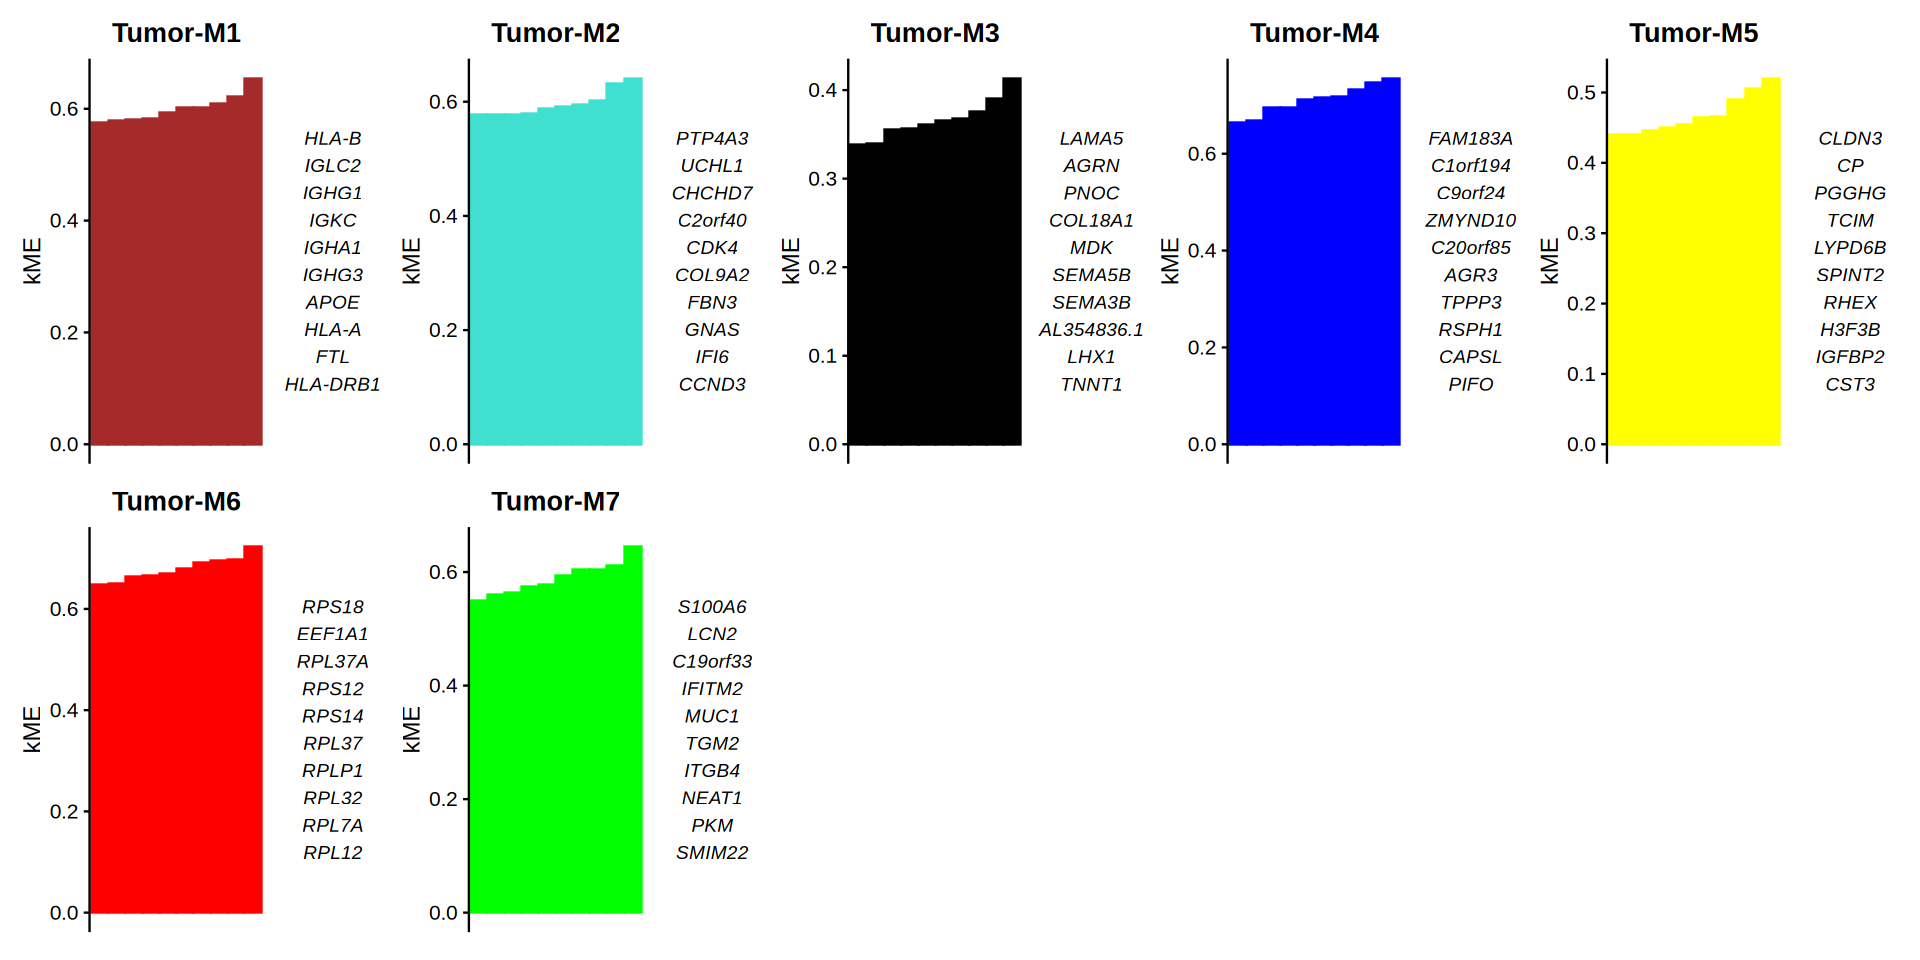

In [14]:
# plot genes ranked by kME for each module
options(repr.plot.height = 8, repr.plot.width = 16)
p <- PlotKMEs(wgcna_obj, ncol=5, text_size = 4)
p

## Module Assignment Table

In [15]:
# get the module assignment table:
modules <- GetModules(wgcna_obj) %>% subset(module != 'grey')
print(dim(modules))
print(table(modules$color))
head(modules, 4)

[1] 4321   11

    black      blue     brown     green       red turquoise    yellow 
       79       711       658       160        90      2040       583 


,gene_name,module,color,kME_Tumor-M1,kME_grey,kME_Tumor-M2,kME_Tumor-M3,kME_Tumor-M4,kME_Tumor-M5,kME_Tumor-M6,kME_Tumor-M7
,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SAMD11,SAMD11,Tumor-M1,brown,0.2865828,0.12833672,0.08841405,0.08904944,0.05003421,0.05388917,-0.12195697,-0.0454291
HES4,HES4,Tumor-M2,turquoise,0.1907851,0.10295618,0.24356937,0.09348385,0.13543220,0.01127069,-0.06516791,-0.1134112
ISG15,ISG15,Tumor-M2,turquoise,0.2499216,0.02305921,0.51636711,0.09705572,-0.08335298,-0.10578838,-0.31272746,-0.3221854
AGRN,AGRN,Tumor-M3,black,0.2988534,0.33637672,0.19034841,0.39053779,0.06189260,0.23617400,-0.06412728,0.1910711


In [16]:
# get hub genes
hub_df <- GetHubGenes(wgcna_obj, n_hubs = 10)
print(dim(hub_df))
head(hub_df, 4)

[1] 70  3


,gene_name,module,kME
,<chr>,<fct>,<dbl>
1,HLA-B,Tumor-M1,0.6547283
2,IGLC2,Tumor-M1,0.6216158
3,IGHG1,Tumor-M1,0.6092280
4,IGKC,Tumor-M1,0.6031249


In [17]:
saveRDS(wgcna_obj, file='./results/ST_tumor_hdWGCNA_object.rds')